# The State of the Thai Freelance Market
### A data snapshot of Fastwork — Thailand's largest freelance marketplace

**What this is.** A random sample of public gig listings from Fastwork, collected and
anonymized, then analyzed to answer practical questions a freelancer or buyer actually has:
*what do people charge, which skills pay best, where is competition concentrated, and what
does "fair value" look like per category?*

**Data & ethics.** Public listings only, collected as an anonymous visitor within
`robots.txt`, rate-limited and cached. Sellers are anonymized — no names, photos, or contact
info — and only **aggregated** statistics are shown. See the project README's
*Ethics & Compliance* section. Not affiliated with or endorsed by Fastwork (บริษัท เช้นจ์ซี จำกัด).

## 0. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 110
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False
pd.set_option('display.float_format', lambda v: f'{v:,.0f}')

df = pd.read_parquet('../data/listings.parquet')
print(f'Loaded {len(df):,} gigs across {df["category_slug"].nunique()} categories')

Loaded 2,935 gigs across 13 categories


## 1. The market at a glance

A quick orientation before we dig in — how big is the sample, how much of it carries social
proof (reviews / sales), and the single headline number: the median starting price.

In [2]:
overview = {
    'Gigs in sample': len(df),
    'Categories': df['category_slug'].nunique(),
    'Unique sellers': df['seller_hash'].nunique(),
    'Gigs with >=1 review': int((df['rating_count'].fillna(0) > 0).sum()),
    'Gigs with >=1 sale': int((df['purchase_count'].fillna(0) > 0).sum()),
    'Median starting price (THB)': df['price_min'].median(),
}
pd.Series(overview)

Gigs in sample                2,935
Categories                       13
Unique sellers                2,899
Gigs with >=1 review            278
Gigs with >=1 sale              310
Median starting price (THB)     550
dtype: float64

## 2. What does the market charge?

The distribution of *starting* prices (the cheapest active package per gig). It is heavily
right-skewed — most work clusters at the low end with a long premium tail, so the **median**
is a far more honest headline than the mean.

count       2,935
mean        3,208
std        41,531
min           100
10%           200
25%           300
50%           550
75%         1,500
90%         3,500
max     2,000,000


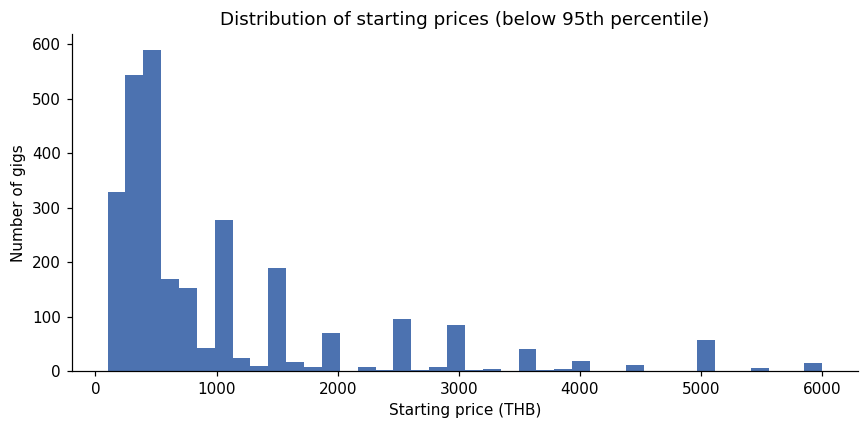

In [3]:
price = df['price_min'].dropna()
print(price.describe(percentiles=[.1,.25,.5,.75,.9]).to_string())

fig, ax = plt.subplots(figsize=(8,4))
price[price < price.quantile(0.95)].plot.hist(bins=40, ax=ax, color='#4C72B0')
ax.set_xlabel('Starting price (THB)'); ax.set_ylabel('Number of gigs')
ax.set_title('Distribution of starting prices (below 95th percentile)')
plt.tight_layout(); plt.show()

## 3. Which skills pay best?

Median starting price by category, with the 25th–75th percentile band so you can see the
spread, not just the midpoint. This is the core table behind a *pricing advisor*.

In [4]:
cat = (df.groupby('category_slug')
         .agg(n_gigs=('gig_id','size'),
              median_price=('price_min','median'),
              p25=('price_min', lambda s: s.quantile(.25)),
              p75=('price_min', lambda s: s.quantile(.75)),
              median_rating=('rating_overall','median'),
              total_sales=('purchase_count','sum'))
         .sort_values('median_price', ascending=False))
cat

,n_gigs,median_price,p25,p75,median_rating,total_sales
category_slug,,,,,,
architect-engineer,120,"3,000","2,500","5,000",5,90
web-programming,137,"2,500","1,500","5,000",5,185
car-rental,32,"1,684","1,088","2,592",5,2
technician,80,"1,500",600,"3,125",5,43
photography-video,206,"1,000","1,000","2,500",5,621
ai-services,44,945,300,"1,199",NaN,3
marketing-advertising,202,900,500,"1,868",5,"2,662"
design-graphic,743,600,500,"1,000",5,"1,509"
consultant,297,500,299,"1,000",5,106


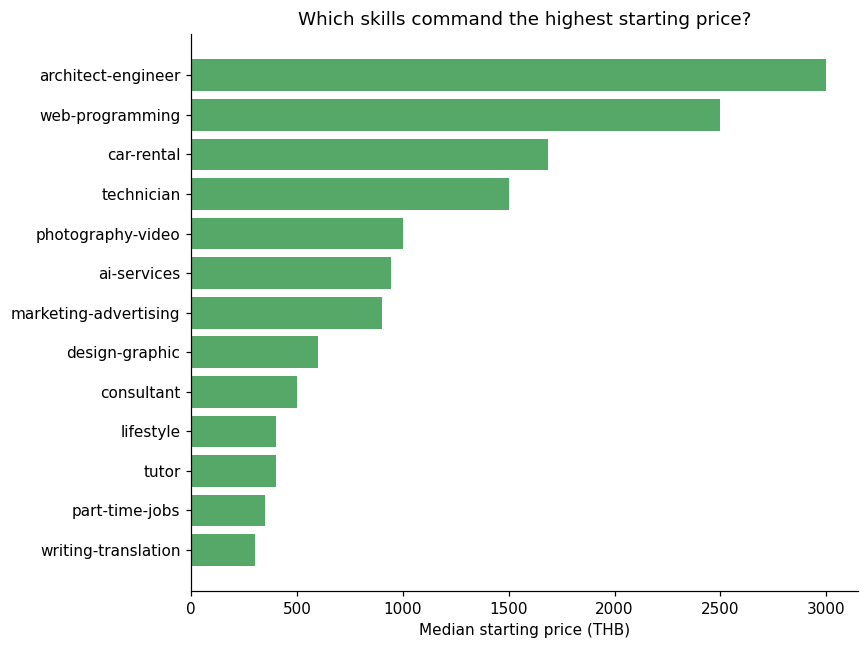

In [5]:
top = cat.sort_values('median_price')
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(top.index, top['median_price'], color='#55A868')
ax.set_xlabel('Median starting price (THB)')
ax.set_title('Which skills command the highest starting price?')
plt.tight_layout(); plt.show()

## 4. Where is the competition?

Supply by category — how many gigs compete in each space. High median price **and** low
supply is the attractive quadrant for a freelancer choosing where to position.

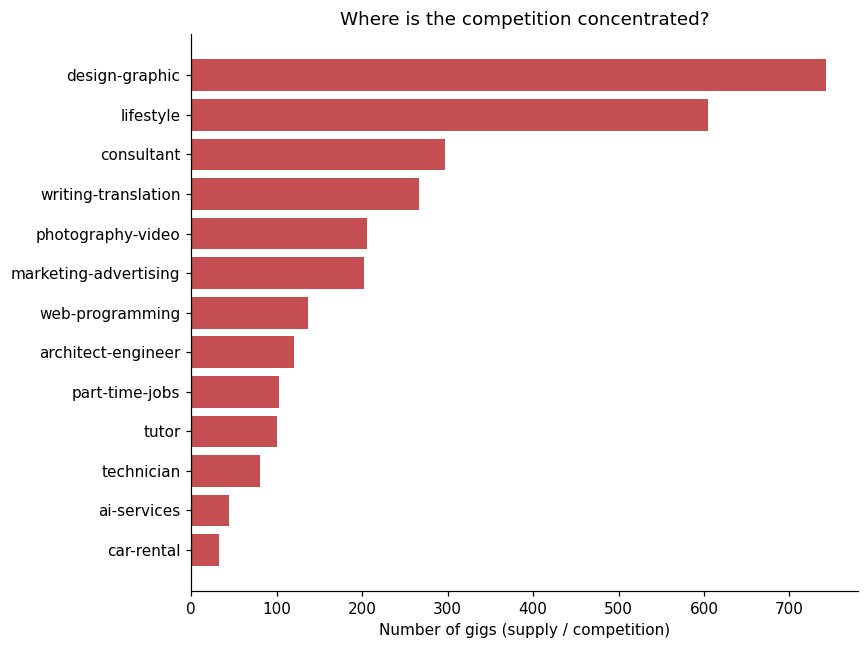

In [6]:
sup = cat.sort_values('n_gigs')
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(sup.index, sup['n_gigs'], color='#C44E52')
ax.set_xlabel('Number of gigs (supply / competition)')
ax.set_title('Where is the competition concentrated?')
plt.tight_layout(); plt.show()

## 5. Price vs. delivery speed

Do faster turnarounds command a premium, or do they signal cheaper, more commoditised work?
We test the relationship between the fastest delivery offered and the starting price.

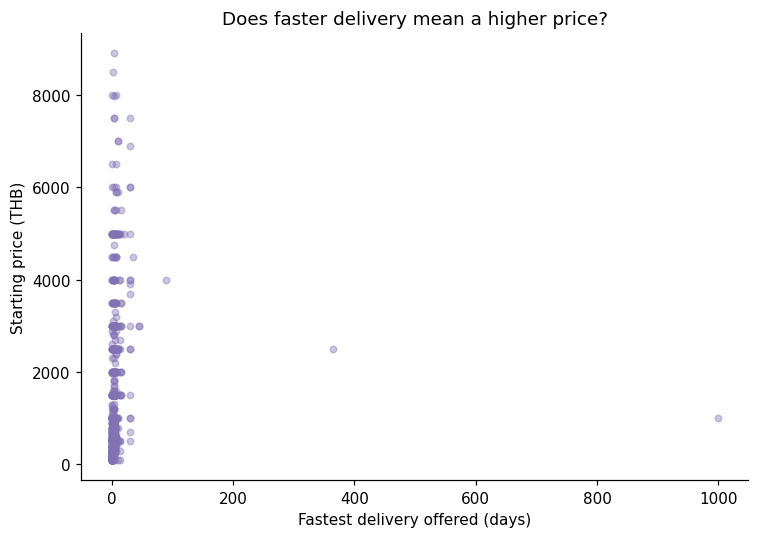

Spearman correlation: 0.448


In [7]:
sub = df.dropna(subset=['price_min','delivery_min_days'])
sub = sub[sub['price_min'] < sub['price_min'].quantile(.95)]
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(sub['delivery_min_days'], sub['price_min'], alpha=.4, s=18, color='#8172B3')
ax.set_xlabel('Fastest delivery offered (days)'); ax.set_ylabel('Starting price (THB)')
ax.set_title('Does faster delivery mean a higher price?')
plt.tight_layout(); plt.show()
print('Spearman correlation:', round(sub['delivery_min_days'].corr(sub['price_min'], method='spearman'), 3))

## 6. Ratings & social proof

How much of the market is *proven*? A large share of gigs carry no reviews yet — which is
itself a finding: ratings are a scarce, valuable signal, and a useful feature for any
ranking or trust model later.

In [8]:
rated = df[df['rating_count'].fillna(0) > 0]
print(f'{len(rated)/len(df):.0%} of gigs have at least one review')
print()
print(rated['rating_overall'].describe().to_string())

9% of gigs have at least one review

count   278
mean      5
std       0
min       2
25%       5
50%       5
75%       5
max       5


## 7. From data to a pricing advisor

The whole point of the table in §3 is that it answers a real question for a real person.
Give it a category and it returns the **budget / typical / premium** price bands — exactly
what a freelancer needs to decide whether they are under- or over-pricing.

In [9]:
def price_benchmark(category_slug):
    s = df.loc[df['category_slug'] == category_slug, 'price_min'].dropna()
    if s.empty:
        return f'no data for {category_slug}'
    return pd.Series({
        'category': category_slug,
        'n_gigs': len(s),
        'budget (p25)': s.quantile(.25),
        'typical (median)': s.median(),
        'premium (p75)': s.quantile(.75),
    })

price_benchmark('design-graphic')

category            design-graphic
n_gigs                         743
budget (p25)                   500
typical (median)               600
premium (p75)                1,000
dtype: object

## Key takeaways

*(generated from the current ~2,900-gig sample; re-running the notebook refreshes these)*

- **Pricing is heavily right-skewed.** The median starting price is **฿550**, but a long
  premium tail (and at least one ฿2,000,000 outlier) drags the mean far higher — the median
  is the only honest headline, and the outliers are exactly what the Phase 3 anomaly model targets.
- **Price and competition pull in opposite directions.** Graphic design is the most crowded
  category (743 gigs) yet among the cheapest (median ฿600); **web/programming (฿2,500)** and
  **architecture/engineering (฿3,000)** combine high prices with far lower supply — the
  attractive quadrant for a freelancer choosing where to compete.
- **Reviews are scarce and ratings barely discriminate.** Only **~9%** of gigs carry any
  review, and almost every rating sits at ~5.0. Star rating is therefore a weak trust signal —
  which is precisely why a data-driven trust/anomaly model (Phase 3) is worth building.

## Methodology, ethics & limitations

- **Sample**: a seeded random sample of public gig URLs from Fastwork's `products` sitemap
  (~222k gigs total), so the snapshot is representative across the whole marketplace.
- **Fields**: read from each gig page's embedded `__NEXT_DATA__` (server-rendered JSON), not
  from scraped HTML. Sellers are anonymized to a hash; no personal fields are stored.
- **Limitations**: a point-in-time snapshot; `price_min` is the cheapest active package and
  ignores scope; review counts are sparse; categories with few gigs have noisy percentiles.
- **Reproduce**: `python src/collect.py --limit 3000 && python src/clean.py`, then re-run this notebook.